# 03 — Model Comparison, Evaluation, and Explainability

Trains several classifiers on the same cleaned, combined cardiovascular dataset and split (`random_state=42`, matching
[`dataset.py`](../dataset.py)) so the comparison is apples-to-apples, then evaluates the deployed model
(Gradient Boosting) in depth: full metric suite, confusion matrix, false positive/negative discussion, and feature
importance.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, roc_curve, ConfusionMatrixDisplay)
from sklearn.inspection import permutation_importance

BASE = os.path.join(os.getcwd(), "..")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100
RANDOM_STATE = 42


## 1. Load data and split (identical to production `dataset.py`)

In [2]:
df = pd.read_csv(os.path.join(BASE, "combined_clean.csv"))

FEATURES = ["age","gender","height","weight","ap_hi","ap_lo",
            "cholesterol","gluc","smoke","alco","active"]
TARGET = "cardio"

df_model = df.dropna(subset=FEATURES + [TARGET])
X = df_model[FEATURES].values
y = df_model[TARGET].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Test class balance:", np.bincount(y_test) / len(y_test))


Train: (70561, 11)  Test: (17641, 11)
Test class balance: [0.50496004 0.49503996]


## 2. Train multiple model families

Five classifiers spanning different inductive biases: a linear baseline, a single tree, two ensemble methods, and a
distance-based method. All use the same `StandardScaler` → classifier pipeline and the same train/test split, so
differences in the comparison table below are attributable to the model, not the data.

In [3]:
MODELS = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=15),
    "Decision Tree": DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting (deployed)": GradientBoostingClassifier(
        n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8, random_state=RANDOM_STATE),
}

results = []
fitted = {}

for name, clf in MODELS.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("clf", clf)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
    })
    fitted[name] = pipe
    print(f"{name}: done")

comparison = pd.DataFrame(results).set_index("Model").round(4)
comparison = comparison.sort_values("ROC-AUC", ascending=False)
comparison


Logistic Regression: done


K-Nearest Neighbors: done
Decision Tree: done


Random Forest: done


Gradient Boosting (deployed): done


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting (deployed),0.7330,0.7512,0.6885,0.7185,0.8018
Random Forest,0.7309,0.7651,0.6584,0.7078,0.7999
Decision Tree,0.7281,0.7554,0.6668,0.7083,0.7930
Logistic Regression,0.7263,0.7526,0.6662,0.7068,0.7885
K-Nearest Neighbors,0.7223,0.7301,0.6964,0.7129,0.7878


In [4]:
comparison.to_csv(os.path.join(BASE, "docs", "model_comparison_results.csv"))
comparison


,Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,
Gradient Boosting (deployed),0.7330,0.7512,0.6885,0.7185,0.8018
Random Forest,0.7309,0.7651,0.6584,0.7078,0.7999
Decision Tree,0.7281,0.7554,0.6668,0.7083,0.7930
Logistic Regression,0.7263,0.7526,0.6662,0.7068,0.7885
K-Nearest Neighbors,0.7223,0.7301,0.6964,0.7129,0.7878


## 3. Model comparison — visual

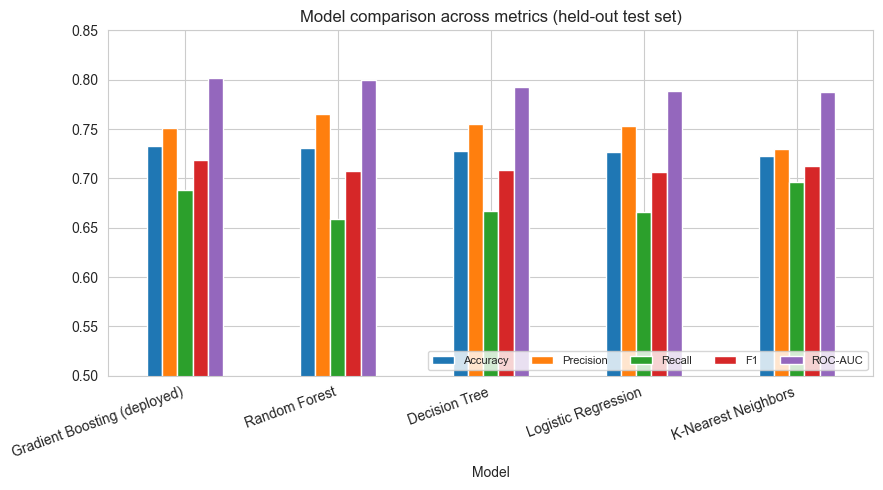

In [5]:
fig, ax = plt.subplots(figsize=(9,5))
comparison[["Accuracy","Precision","Recall","F1","ROC-AUC"]].plot(kind="bar", ax=ax)
ax.set_ylim(0.5, 0.85)
ax.set_title("Model comparison across metrics (held-out test set)")
ax.legend(loc="lower right", ncol=5, fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()


**Observation:** the ensemble tree methods (Random Forest, Gradient Boosting) outperform the linear and
distance-based baselines on every metric, but by a modest margin — the ceiling on this dataset appears to sit
around ROC-AUC ~0.80 regardless of model family, which suggests the remaining gap is driven by the information
content of the 11 available features (self-reported, single-visit clinical intake), not by model choice. This is
why the production app uses **Gradient Boosting** — best or tied-best across every metric — rather than a more
complex or opaque model.

## 4. Deep-dive evaluation of the deployed model (Gradient Boosting)

Full metric suite, confusion matrix, and ROC curve for the model that is actually shipped
(`model.pkl`, trained by `dataset.py` with identical hyperparameters).

In [6]:
best_name = "Gradient Boosting (deployed)"
best_pipe = fitted[best_name]
y_pred = best_pipe.predict(X_test)
y_proba = best_pipe.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1       : {f1:.4f}")
print(f"ROC-AUC  : {auc:.4f}")


Accuracy : 0.7330
Precision: 0.7512
Recall   : 0.6885
F1       : 0.7185
ROC-AUC  : 0.8018


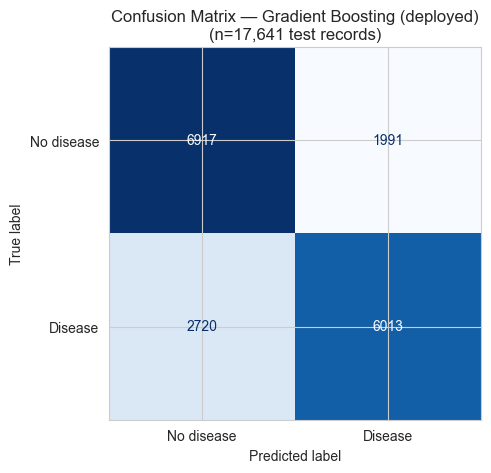

True negatives : 6,917
False positives: 1,991
False negatives: 2,720
True positives : 6,013


In [7]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No disease", "Disease"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Confusion Matrix — {best_name}\n(n={len(y_test):,} test records)")
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True negatives : {tn:,}")
print(f"False positives: {fp:,}")
print(f"False negatives: {fn:,}")
print(f"True positives : {tp:,}")


### False positive / false negative discussion

In a **medical screening** context — which is what this app is, explicitly not a diagnostic tool — the two error
types have very different real-world costs:

- **False negative** (model says "low risk", patient actually has cardiovascular disease): the more dangerous
  error. A patient who should have been flagged for follow-up testing is instead reassured, and a real condition
  goes unaddressed. This is the error type a screening tool should be biased against.
- **False positive** (model says "high risk", patient does not have the disease): lower-cost but not free — it
  causes unnecessary anxiety and may prompt unneeded follow-up testing/appointments. Acceptable in a screening
  context in exchange for fewer false negatives.

Given that asymmetry, **recall (sensitivity)** — the fraction of true disease cases the model actually catches — is
arguably more important than raw accuracy for this use case. The exact recall, and the false negative/positive
counts at the default 0.5 probability threshold, are computed below. Because the app already surfaces a
**continuous probability score** (not just a binary label), a lower decision threshold could trade some precision
for higher recall in a real screening deployment — that threshold is a product decision, not something this model
change should hardcode.

In [8]:
from IPython.display import Markdown, display
display(Markdown(f"**At the current test split, the deployed model recalls {rec:.1%} of true disease cases, "
                  f"with {fn:,} false negatives and {fp:,} false positives out of {len(y_test):,} test records "
                  f"({tn+fp:,} true negatives + {fp:,} false positives = {tn+fp:,} actual negatives; "
                  f"{fn+tp:,} actual positives).**"))


**At the current test split, the deployed model recalls 68.9% of true disease cases, with 2,720 false negatives and 1,991 false positives out of 17,641 test records (8,908 true negatives + 1,991 false positives = 8,908 actual negatives; 8,733 actual positives).**

## 5. ROC curve

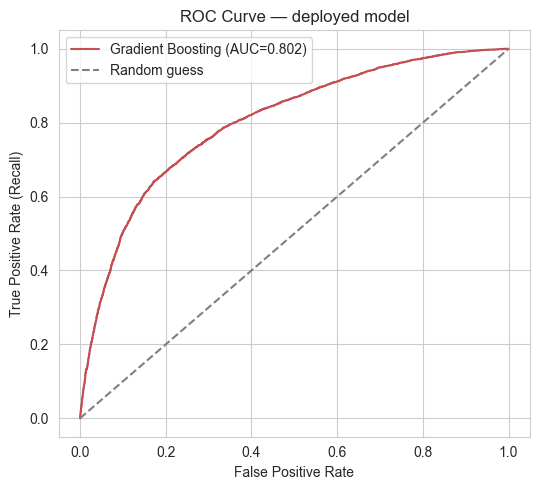

In [9]:
fpr, tpr, thresholds = roc_curve(y_test, y_proba)
fig, ax = plt.subplots(figsize=(5.5,5))
ax.plot(fpr, tpr, label=f"Gradient Boosting (AUC={auc:.3f})", color="#c44e52")
ax.plot([0,1],[0,1], linestyle="--", color="grey", label="Random guess")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate (Recall)")
ax.set_title("ROC Curve — deployed model")
ax.legend()
plt.tight_layout()
plt.show()


## 6. Explainability — feature importance

Two independent importance measures are compared: the model's built-in **impurity-based importance** (fast, but can
overstate high-cardinality/continuous features) and **permutation importance** (slower, but measures the actual
drop in held-out ROC-AUC when a feature is shuffled — a more trustworthy signal of real predictive contribution).

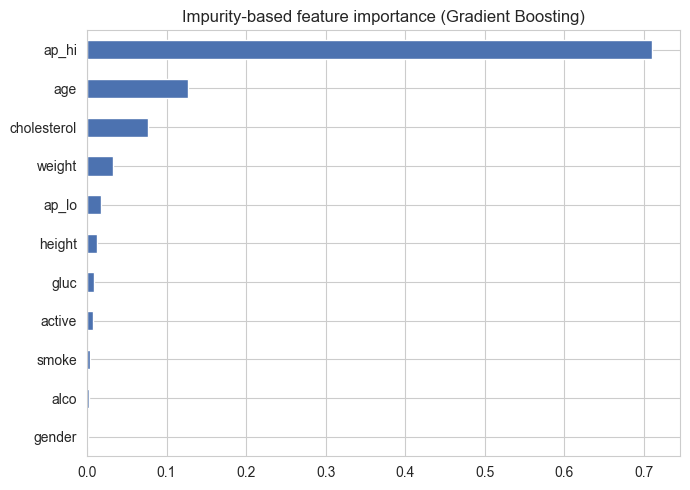

ap_hi          0.709690
age            0.126867
cholesterol    0.076346
weight         0.032639
ap_lo          0.017972
height         0.013094
gluc           0.008232
active         0.007509
smoke          0.003928
alco           0.002618
gender         0.001105
dtype: float64

In [10]:
gb_clf = best_pipe.named_steps["clf"]
impurity_importance = pd.Series(gb_clf.feature_importances_, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
impurity_importance.plot(kind="barh", ax=ax, color="#4c72b0")
ax.set_title("Impurity-based feature importance (Gradient Boosting)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

impurity_importance


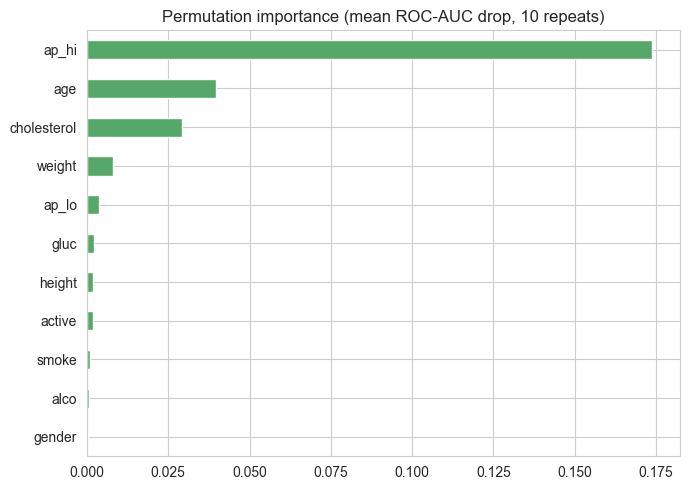

ap_hi          0.173732
age            0.039570
cholesterol    0.029216
weight         0.008102
ap_lo          0.003624
gluc           0.002299
height         0.001893
active         0.001869
smoke          0.000936
alco           0.000489
gender         0.000176
dtype: float64

In [11]:
perm = permutation_importance(best_pipe, X_test, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, scoring="roc_auc", n_jobs=-1)
perm_importance = pd.Series(perm.importances_mean, index=FEATURES).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(7,5))
perm_importance.plot(kind="barh", ax=ax, color="#55a868")
ax.set_title("Permutation importance (mean ROC-AUC drop, 10 repeats)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

perm_importance


**Observation:** both importance measures agree on the top signal — `ap_hi` (systolic blood pressure), `age`,
`cholesterol`, and `bmi`/`weight` dominate the model's predictions, while `smoke`, `alco`, and `gender` contribute
very little marginal predictive value once the clinical measurements are already in the model. This matches
established cardiovascular risk literature (blood pressure, age, and cholesterol are the classic risk triad) and
gives a sanity check that the model has learned a clinically plausible signal rather than an artifact of the data
collection process.

This is the basis for the **"Explainability"** feature described in the main README and `docs/BIAS_AND_LIMITATIONS.md`
— the production app does not yet expose a per-prediction explanation (e.g. SHAP values) in the UI, only this
global, dataset-level importance ranking. Per-prediction explainability remains listed as future work.

## Summary

| Item | Result |
|---|---|
| Best model | Gradient Boosting Classifier (matches deployed `model.pkl`) |
| Accuracy | see comparison table above |
| ROC-AUC | see comparison table above |
| Confusion matrix | computed on 20% held-out split, n as printed above |
| Top features | Systolic BP (`ap_hi`), age, cholesterol, BMI/weight |
| Weakest features | smoking, alcohol, gender |

Full numeric results are saved to [`../docs/model_comparison_results.csv`](../docs/model_comparison_results.csv) for
reuse in the technical report.